<a href="https://colab.research.google.com/github/rajkumar123sudo/rajkumar12345/blob/main/Copy_of_netflix_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  show_id     type                          title             director  \
0      s8    Movie                        Sankofa         Haile Gerima   
1      s9  TV Show  The Great British Baking Show      Andy Devonshire   
2     s10    Movie                   The Starling       Theodore Melfi   
3     s13    Movie                   Je Suis Karl  Christian Schwochow   
4     s25    Movie                          Jeans           S. Shankar   

                                                cast  \
0  Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...   
1  Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...   
2  Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...   
3  Luna Wedler, Jannis Niewöhner, Milan Peschel, ...   
4  Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...   

                                             country          date_added  \
0  United States, Ghana, Burkina Faso, United Kin...  September 24, 2021   
1                                     United Kingdom  September 24

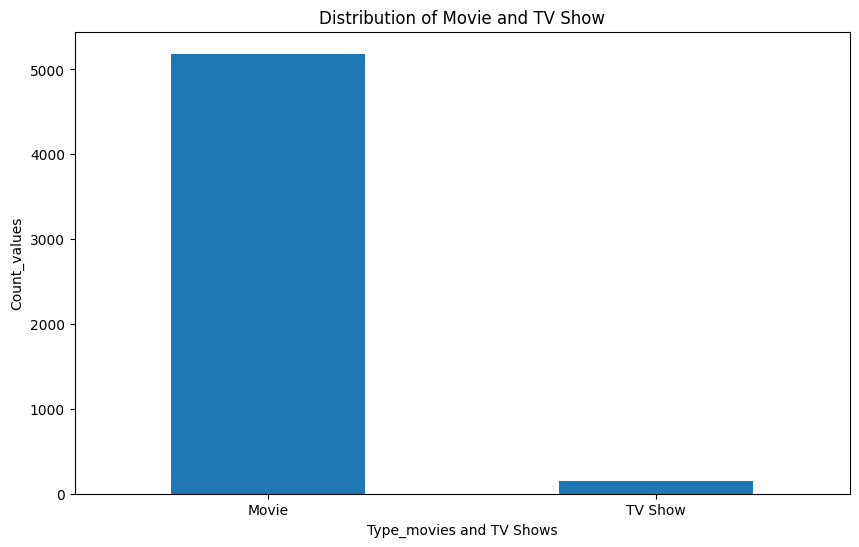

<Figure size 640x480 with 0 Axes>

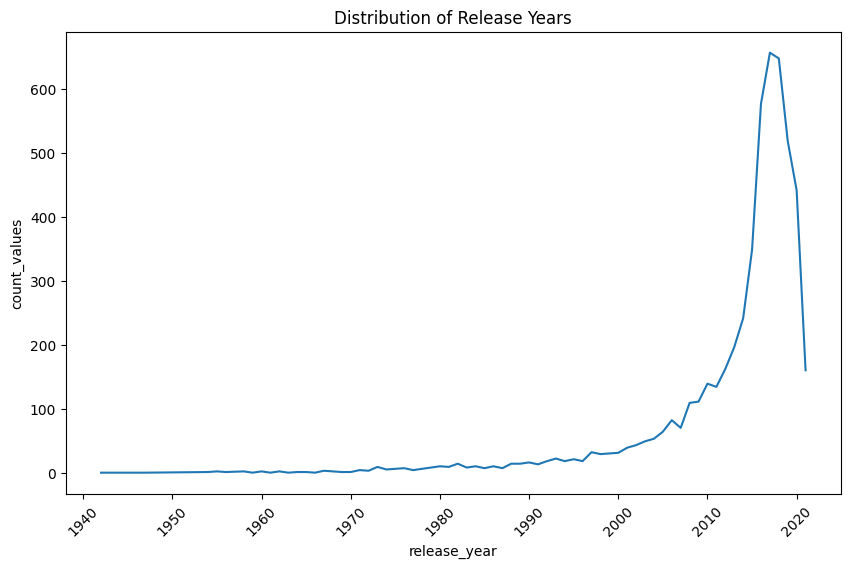

<Figure size 640x480 with 0 Axes>

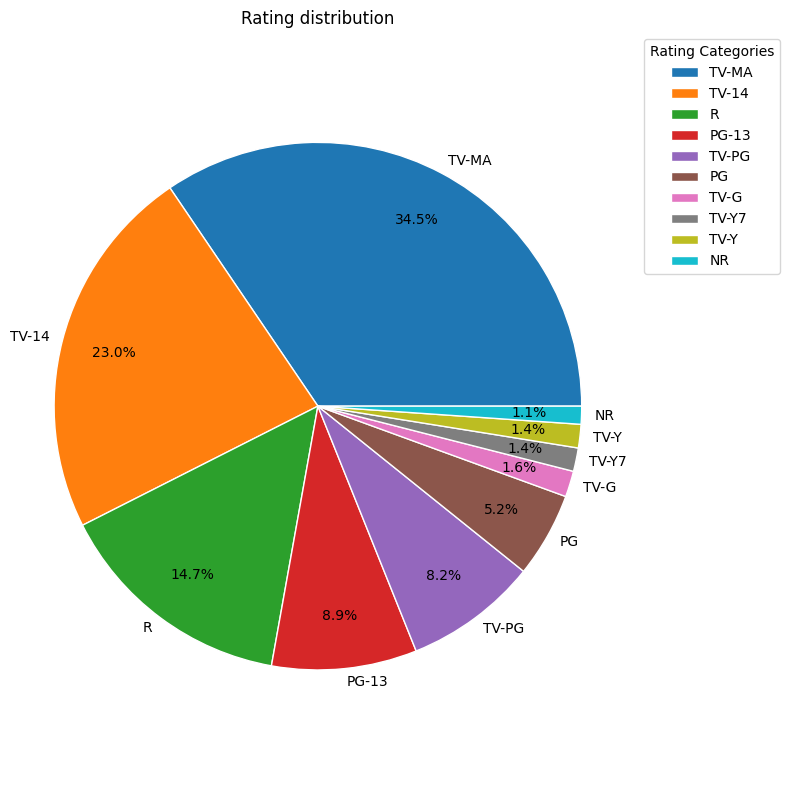

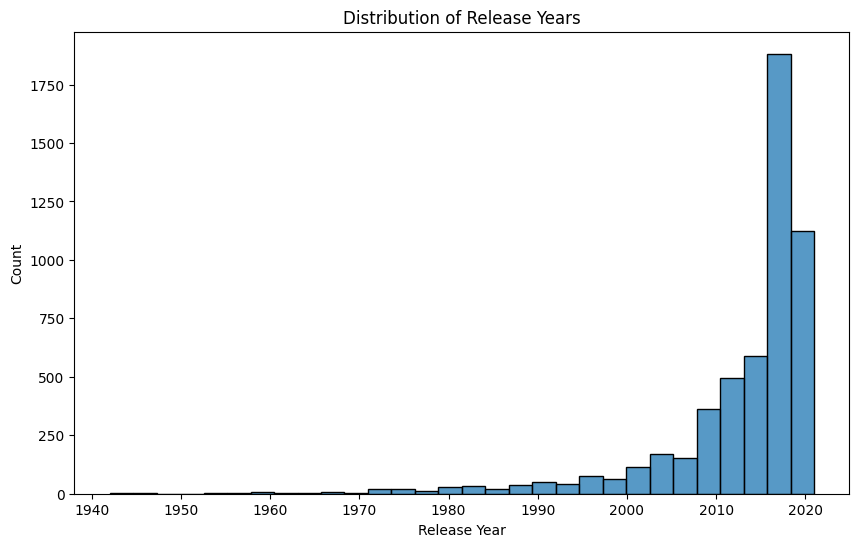

<Figure size 640x480 with 0 Axes>

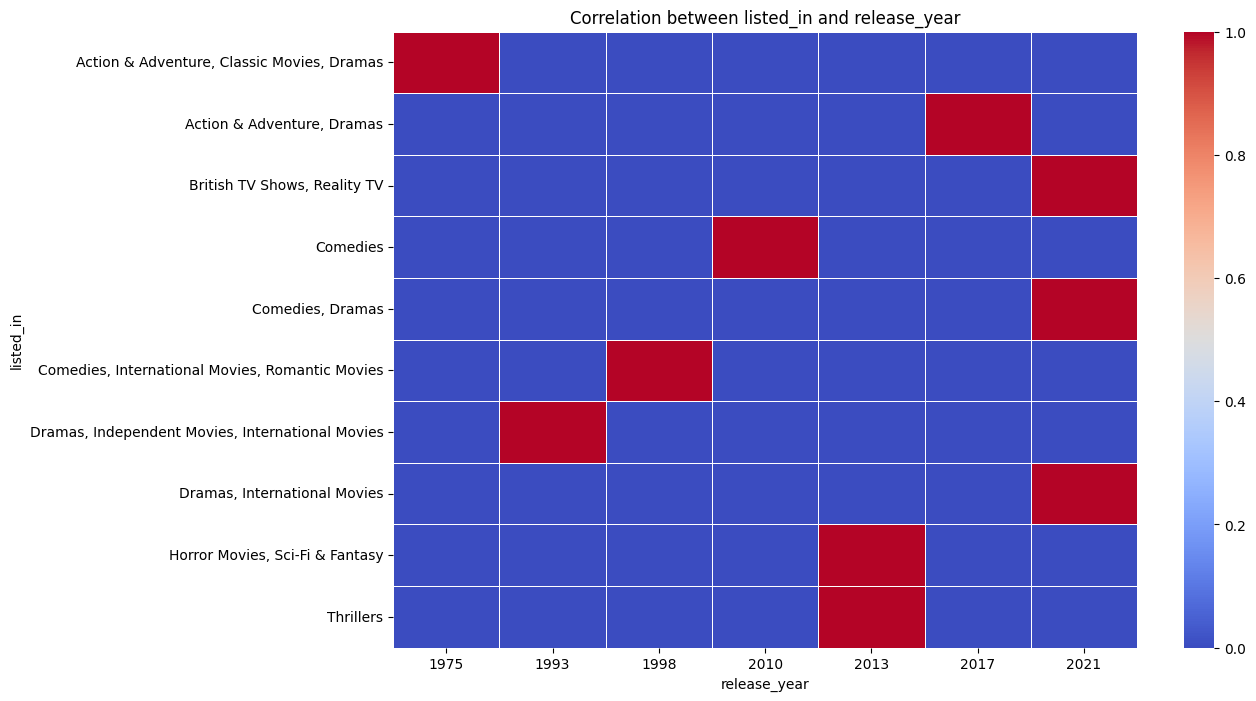

<Figure size 640x480 with 0 Axes>

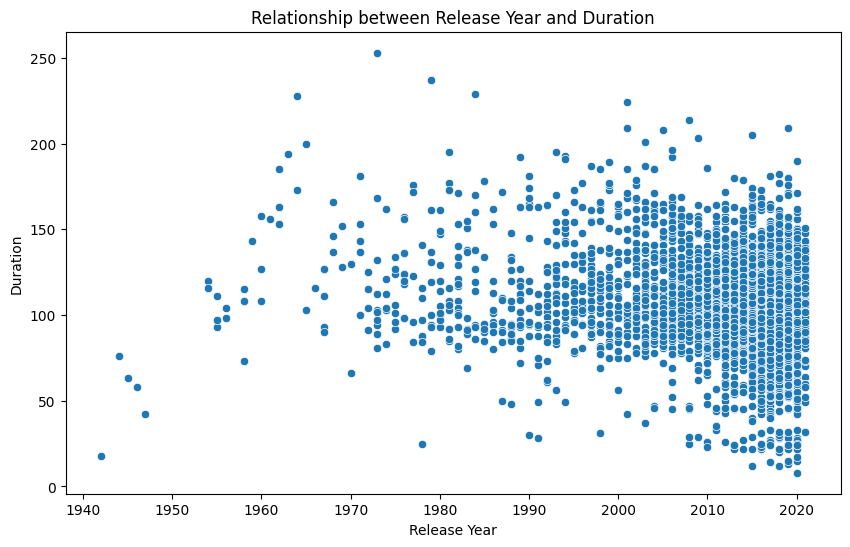

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns


df = pd.read_csv(r"/netflix_titles_cleaned.csv")
print(df.head(5))
df.describe()
df.info()
df.shape


# this is a bar chart to show the distribution of movie and TV show in the dataset
plt.figure(figsize=(10, 6))
df['type'].value_counts().plot(kind='bar')
plt.title('Distribution of Movie and TV Show')
plt.xlabel('Type_movies and TV Shows')
plt.ylabel('Count_values')
plt.xticks(rotation=0)
plt.show()
plt.savefig("bar_charts.png")


# this is a line chart to show the distribution of release years in the dataset
plt.figure(figsize=(10, 6))
df['release_year'].value_counts().sort_index().plot(kind='line')
plt.title('Distribution of Release Years')
plt.xlabel("release_year")
plt.ylabel('count_values')
plt.xticks(rotation=45)
plt.show()
plt.savefig("line_chart.png")

# this is a pie chart to show the distribution of ratings in the dataset
# rating distribution
rating_counts = df['rating'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct='%1.1f%%',
    # startangle=140,
    pctdistance=0.8,
    labeldistance=1.05,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
ax.axis('equal')
plt.title('Rating distribution')
plt.legend(
    title='Rating Categories',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.savefig('pie_chart.png')
plt.show()

# this is a histogram to show the distribution of release years in the dataset
plt.figure(figsize=(10, 6))
sns.histplot(df['release_year'], bins=30, )
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()
plt.savefig("histogram.png")


# heatmap to show the correlation between top 10 listed_in and release_year in the dataset
plt.figure(figsize=(12, 8))
plt.title('Correlation between listed_in and release_year')
heat_data = pd.crosstab(df['listed_in'].head(10), df['release_year'])
sns.heatmap(heat_data, cmap='coolwarm', linewidths=0.5)
plt.show()
plt.savefig("heatmap.png")
# heatmap to show listed_in in the dataset

# scatter plot to show the relationship between release_year and duration in the dataset
plt.figure(figsize=(10, 6))
# convert duration strings (minutes) to numeric, ignore "Seasons"
df['duration_num'] = np.nan
mask_min = df['duration'].str.contains('min', na=False)
df.loc[mask_min, 'duration_num'] = pd.to_numeric(df.loc[mask_min, 'duration'].str.extract(r'(\d+)')[0], errors='coerce')

sns.scatterplot(x='release_year', y='duration_num', data=df)
plt.title('Relationship between Release Year and Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration')
plt.show()
plt.savefig("scatter_plot.png")

